In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

sns.set_style("whitegrid")

In [5]:
df = pd.read_csv("Wine Quality Red.csv")

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

df.head()

Dataset Shape: (1599, 12)

Column Names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [6]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [7]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 240


In [8]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [9]:
quality_counts = df["quality"].value_counts().sort_index()

quality_table = pd.DataFrame({
    "Quality Score": quality_counts.index,
    "Number of Wines": quality_counts.values
})

quality_table

,Quality Score,Number of Wines
0,3,10
1,4,53
2,5,681
3,6,638
4,7,199
5,8,18


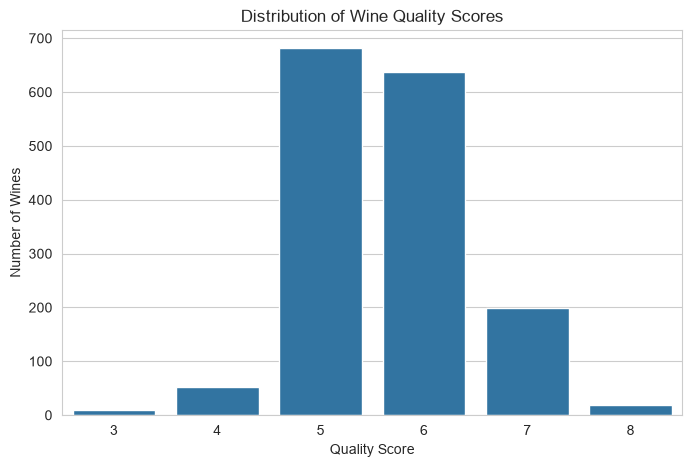

In [11]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="quality",
    data=df,
    order=sorted(df["quality"].unique())
)

plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Number of Wines")

plt.show()

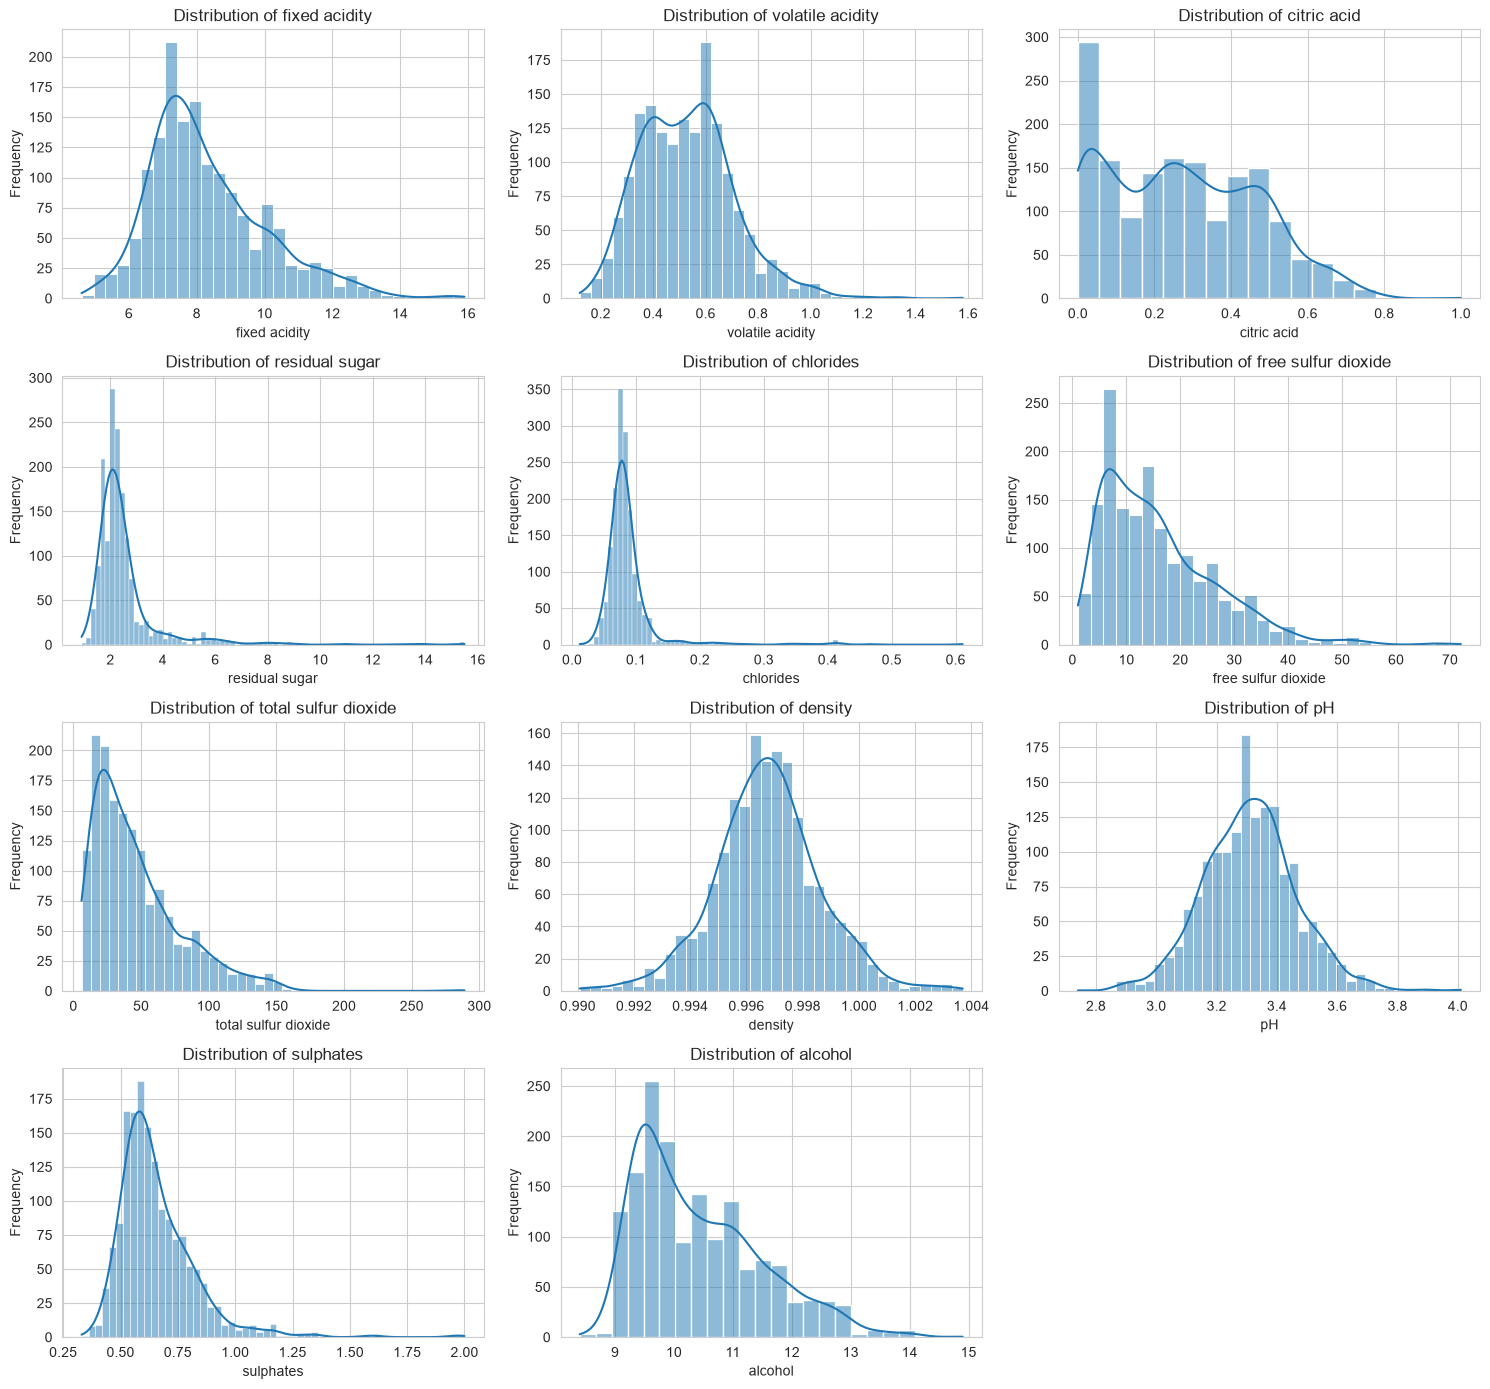

In [11]:
features = df.drop(columns=["quality"]).columns

fig, axes = plt.subplots(4, 3, figsize=(15, 14))

axes = axes.flatten()

for i, column in enumerate(features):
    sns.histplot(
        df[column],
        kde=True,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribution of {column}")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Frequency")

# Hide unused subplot
for i in range(len(features), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

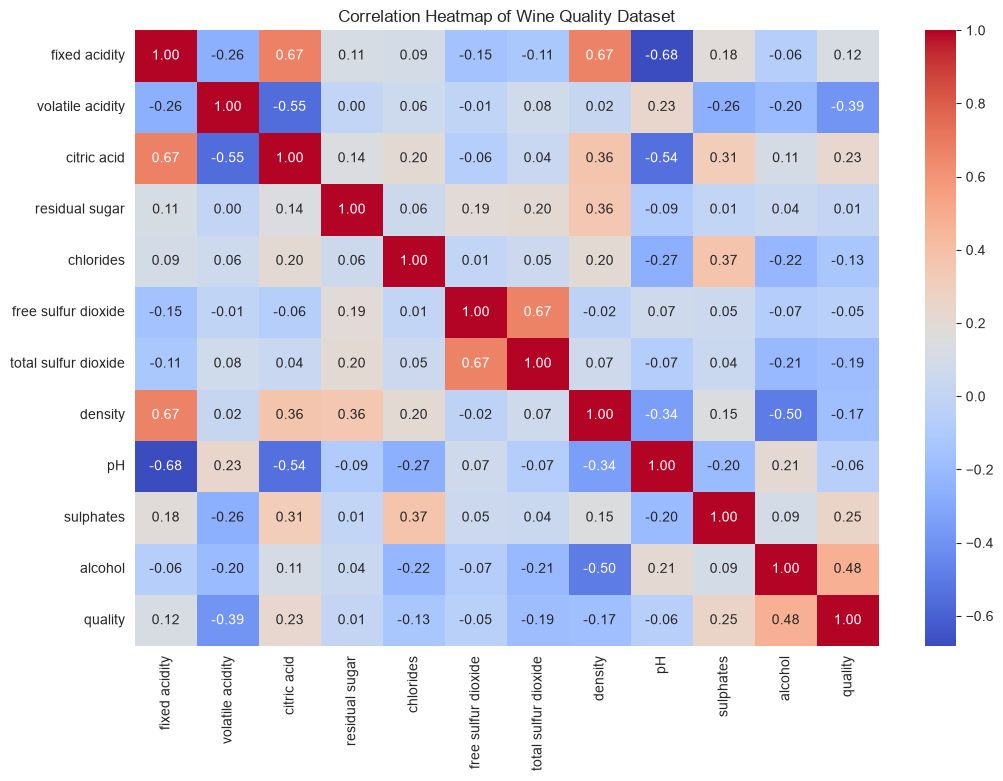

In [12]:
plt.figure(figsize=(12, 8))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Wine Quality Dataset")

plt.show()

In [13]:
df["quality_label"] = df["quality"].apply(
    lambda x: 1 if x >= 7 else 0
)

label_counts = df["quality_label"].value_counts().sort_index()

class_table = pd.DataFrame({
    "Class": ["Not Good", "Good"],
    "Label": [0, 1],
    "Number of Wines": [
        label_counts.get(0, 0),
        label_counts.get(1, 0)
    ]
})

class_table

,Class,Label,Number of Wines
0,Not Good,0,1382
1,Good,1,217


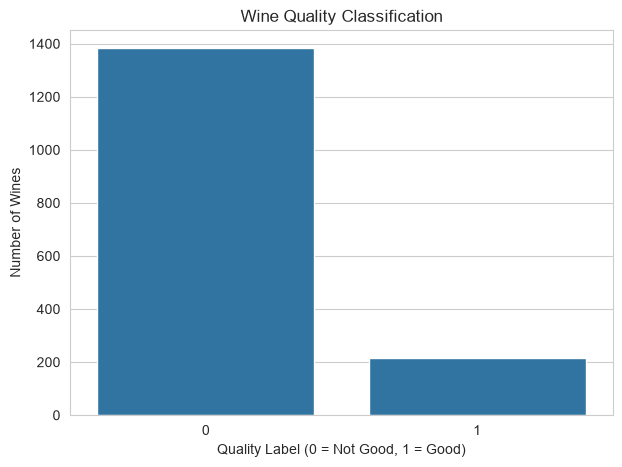

In [14]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x="quality_label",
    data=df
)

plt.title("Wine Quality Classification")
plt.xlabel("Quality Label (0 = Not Good, 1 = Good)")
plt.ylabel("Number of Wines")

plt.show()

In [24]:
# Separate features and target
X = df.drop(["quality", "quality_label"], axis=1)
y = df["quality_label"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (1279, 11)
Testing set size: (320, 11)


In [25]:
# Define all three models
# Train the three models and generate predictions

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "SGD Classifier": SGDClassifier(
        random_state=42,
        max_iter=1000
    ),

    "Support Vector Classifier": SVC(
        kernel="rbf",
        random_state=42
    )
}

predictions = {}

for name, model in models.items():

    if name == "Random Forest":
        model.fit(X_train, y_train)
        predictions[name] = model.predict(X_test)

    else:
        model.fit(X_train_scaled, y_train)
        predictions[name] = model.predict(X_test_scaled)

    print(f"{name} training completed.")

Random Forest training completed.
SGD Classifier training completed.
Support Vector Classifier training completed.


In [26]:
results = []

for name, y_pred in predictions.items():
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.94375,0.931034,0.627907,0.750000
1,Support Vector Classifier,0.90000,0.761905,0.372093,0.500000
2,SGD Classifier,0.86875,0.512821,0.465116,0.487805


In [28]:
results_display = results_df.copy()

for column in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    results_display[column] = (
        results_display[column] * 100
    ).round(2).astype(str) + "%"

results_display

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,94.38%,93.1%,62.79%,75.0%
1,Support Vector Classifier,90.0%,76.19%,37.21%,50.0%
2,SGD Classifier,86.88%,51.28%,46.51%,48.78%


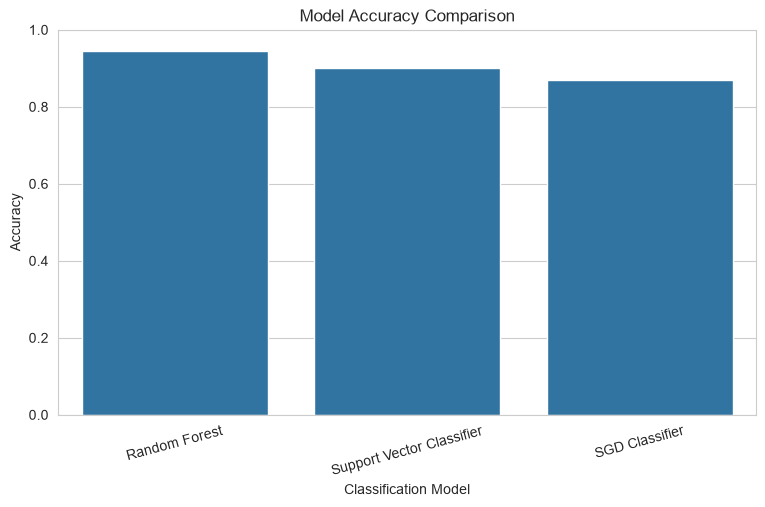

In [27]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Classification Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.xticks(rotation=15)

plt.show()

In [29]:
# Retrain Random Forest and get detailed metrics
for name, y_pred in predictions.items():
    
    print("=" * 60)
    print(name)
    print("=" * 60)
    
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Not Good", "Good"],
            zero_division=0
        )
    )

Random Forest
              precision    recall  f1-score   support

    Not Good       0.95      0.99      0.97       277
        Good       0.93      0.63      0.75        43

    accuracy                           0.94       320
   macro avg       0.94      0.81      0.86       320
weighted avg       0.94      0.94      0.94       320

SGD Classifier
              precision    recall  f1-score   support

    Not Good       0.92      0.93      0.92       277
        Good       0.51      0.47      0.49        43

    accuracy                           0.87       320
   macro avg       0.72      0.70      0.71       320
weighted avg       0.86      0.87      0.87       320

Support Vector Classifier
              precision    recall  f1-score   support

    Not Good       0.91      0.98      0.94       277
        Good       0.76      0.37      0.50        43

    accuracy                           0.90       320
   macro avg       0.84      0.68      0.72       320
weighted avg       

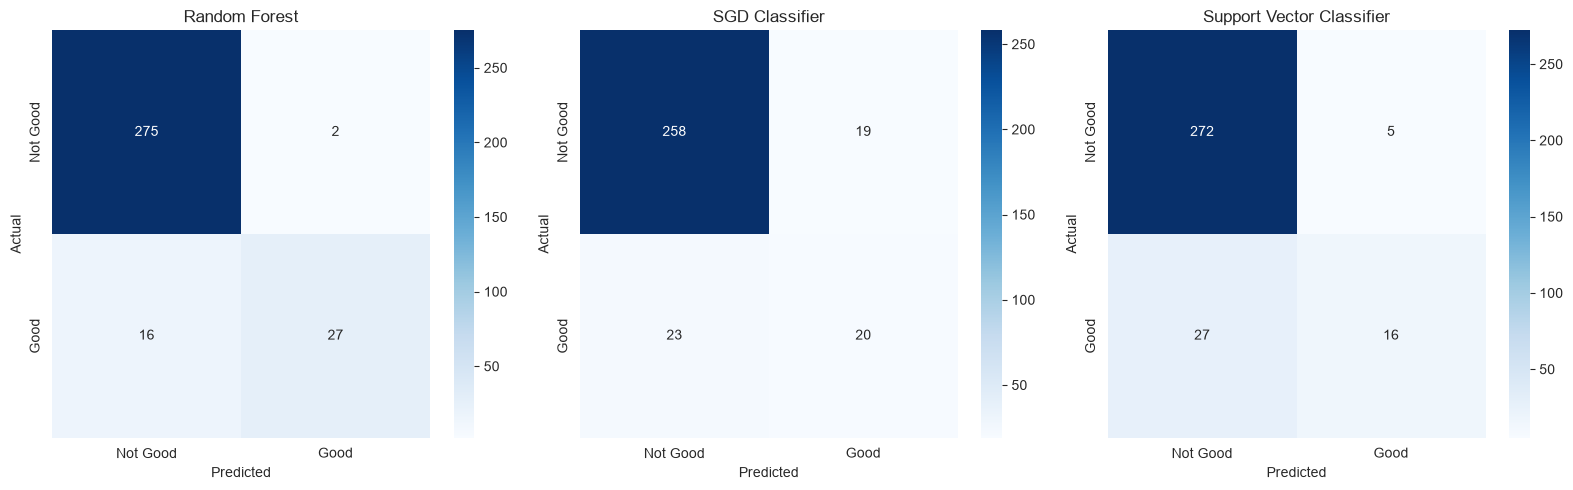

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Not Good", "Good"],
        yticklabels=["Not Good", "Good"],
        ax=ax
    )
    
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [31]:
rf_model = models["Random Forest"]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
10,alcohol,0.173564
9,sulphates,0.111345
7,density,0.102920
1,volatile acidity,0.102421
2,citric acid,0.093135
6,total sulfur dioxide,0.078180
0,fixed acidity,0.076296
3,residual sugar,0.069652
4,chlorides,0.068110
8,pH,0.065280


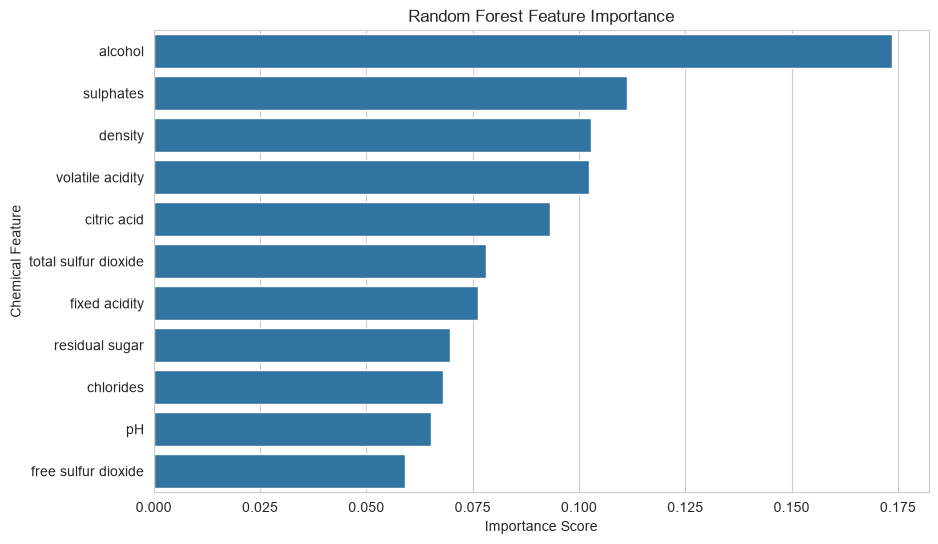

In [32]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Chemical Feature")

plt.show()

In [33]:
feature_importance.head(10)

,Feature,Importance
10,alcohol,0.173564
9,sulphates,0.111345
7,density,0.102920
1,volatile acidity,0.102421
2,citric acid,0.093135
6,total sulfur dioxide,0.078180
0,fixed acidity,0.076296
3,residual sugar,0.069652
4,chlorides,0.068110
8,pH,0.065280


In [34]:
best_model = results_df.iloc[0]

print("Best Model:", best_model["Model"])
print(f"Accuracy: {best_model['Accuracy'] * 100:.2f}%")
print(f"Precision: {best_model['Precision'] * 100:.2f}%")
print(f"Recall: {best_model['Recall'] * 100:.2f}%")
print(f"F1 Score: {best_model['F1 Score'] * 100:.2f}%")

Best Model: Random Forest
Accuracy: 94.38%
Precision: 93.10%
Recall: 62.79%
F1 Score: 75.00%


## Insights and Recommendations

1. Dataset Overview
The dataset contains 1,599 red wine samples with 11 physicochemical features used to predict wine quality. No missing values were identified, so no missing-value treatment was required.
2. Quality Distribution and Class Imbalance
Most wines have quality scores of 5 or 6, while only a small number receive very low or high quality scores. This creates an imbalanced distribution, particularly after converting the target into Good and Not Good categories.
3. Binary Classification
The original quality scores were converted into a binary classification problem. Wines with a quality score of 7 or higher were classified as "Good", while wines with scores below 7 were classified as "Not Good." This simplified the prediction task and allowed the three classification models to be compared consistently.
4. Model Performance
Three classification algorithms were evaluated: Random Forest, SGD Classifier, and Support Vector Classifier (SVC). In the current experiment, Random Forest achieved the best overall performance with an accuracy of 94.38%, along with 93.10% precision, 62.79% recall, and a 75.00% F1-score.
5. Recommended Model
Based on the current results, Random Forest is the most suitable model among the three tested approaches. Its high accuracy and precision indicate strong overall classification performance. However, its lower recall for the Good class suggests that some good-quality wines may still be classified as Not Good.
6. Important Features
The Random Forest feature-importance analysis identified alcohol as the most influential feature, followed by sulphates, density, volatile acidity, and citric acid. These results indicate that these physicochemical properties contribute strongly to the model's predictions. However, feature importance represents the model's predictive contribution and should not be interpreted as direct causation.
7. Recommendations for Improvement
Because the dataset has an imbalanced class distribution, techniques such as SMOTE, class weighting, or other resampling methods could be explored to improve the model's ability to identify the minority class. Further improvements could also include hyperparameter tuning and cross-validation to achieve more reliable and potentially better-performing models.

## Conclusion

The analysis successfully developed and compared three classification models for predicting red wine quality. Among the tested models, Random Forest achieved the strongest overall performance, with an accuracy of 94.38%.

The feature-importance analysis showed that alcohol, sulphates, density, volatile acidity, and citric acid were among the most influential features used by the Random Forest model. However, the class imbalance in the dataset remains an important limitation, as reflected by the lower recall for the Good wine category.

Overall, Random Forest is the most suitable model among the three approaches tested in this project. Future work could improve the model by applying class-balancing techniques such as SMOTE, performing hyperparameter tuning, and using cross-validation.